# Spotify Lab: Vectors, Inner Products, and Similar Songs

**Name(s):** Aryan Thodupunuri

You are a new data engineer at Spotify.

When a listener asks for songs with similar content, we want to query the library of music and select appropriate recommendations. 

Every song is represented as a vector, and we are using a **vector database**: Each song is encoded as a vector of word counts. So if "love" appears 12 times in the song, the "love" coordinate is $x_{\text{love}}=12$. If Metallica writes songs about topics that are more similar to Black Sabbath than to Josh Groban, then the vector representations of their songs will have more similar profiles, and we should suggest Black Sabbath over Josh Groban. This approach is fundamental to technologies like LLMs or facial recognition, which store documents and faces as vectors and conducts fast look-ups using the kinds of math we'll look at in this lab.

The main data, `song_vectors.csv.gz`, include:

- `track_id`, `song_id`, `artist_id`: Internal unique track identifiers
- `artist_name`, `song_title`, `release`: Artist, song, album
- `release_year`, `duration`: `
- `artist_familiarity`, `artist_hotttnesss`: Measures of ubiquity, popularity
- `genre`, `top_tags`: Information about the song type
- `n_words`, `nnz_words`, `l2_norm`: Number of total words in the song, number of non-zero word coordinates (i.e. number of unique words), and the word counts squared/summed/square-rooted.
- `is_test`: Train-test split identification
- 800 columns of word counts

The `top_40_songs_by_genre.csv` file contains the top 40 songs by genre -- rock, metal, pop, punk, country, r&b/soul, folk, hip hop, electronic, blues, jazz, reggae, latin, classical -- by "hotttness". We'll use these songs to benchmark.

The `vocabulary.csv` file includes the 800 words that form the vector space in which the songs are modeled.

Each song becomes a vector of lyric-word counts, and then we use vector operations to quantify "similarity".

The big goal of this lab is simple:

**Vectors and inner products and vector length are the core tools of modern retrieval systems.**

## Setup

We will use:

- `./data/song_vectors.csv.gz`: one row per song
- `./data/vocabulary.csv`: the word columns used in the song vectors

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


songs = pd.read_csv( "./data/song_vectors.csv.gz" )
vocab = pd.read_csv( "./data/vocabulary.csv" )
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist() # Song count matrix
meta_cols = songs.columns.drop(word_cols).tolist() # Information about tracks

print('Number of songs, number of words:', songs.shape)
print( 'Song metadata fields:', meta_cols[:8])

Number of songs, number of words: (8000, 816)
Song metadata fields: ['track_id', 'song_id', 'artist_id', 'artist_name', 'song_title', 'release', 'release_year', 'duration']


In [2]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Similarity Measures for Song Vectors

The word-count columns are coordinates. That means each song is a vector in a high-dimensional space.

We will work with the song-by-word matrix $X$, where each row is one song vector.

In [3]:
X = songs[word_cols].to_numpy(dtype=float)

query_idx = 0 # Let's query the first song
query = X[query_idx]

print( 'Track metadata: \n')
print(songs.loc[query_idx, meta_cols])

print( 'Track word counts: \n')
print( query )

Track metadata: 

track_id                                            TRAAPIV128F1493132
song_id                                             SOJHKYL12A6D4FA0AC
artist_id                                           AR56P361187B9AC4DB
artist_name                                                 Gary Moore
song_title                                        What Are We Here For
release                                          Dark Days In Paradise
release_year                                                      1997
duration                                                     345.93914
artist_familiarity                                            0.761362
artist_hotttnesss                                             0.467111
genre                                                            blues
top_tags              blues; classic rock; rock; hard rock; blues rock
n_words                                                            218
nnz_words                                                  

In [4]:
# Let's see the counts for nonzero words

nonzero = np.flatnonzero(query)

pd.DataFrame({
    "word": np.array(word_cols)[nonzero],
    "count": query[nonzero].astype(int),
}).sort_values("count", ascending=False).head(15)

,word,count
62,we,27
4,are,10
17,for,9
37,of,7
63,what,6
26,it,6
21,here,6
20,have,6
41,our,5
54,through,5


## Step 1: Dot Product

The dot product is our first similarity score:

$$
x \cdot y = \sum_{j=1}^m x_j y_j
$$

It gets large when two songs align count mass on the same words. 

It also tends to go up for longer songs or songs with larger total counts, which is a choice we'll have to think about.

In [5]:
# Compute the dot product between every song vector and the query vector.
dot_scores = X @ query

dot_results = songs[meta_cols].copy()
dot_results["dot"] = dot_scores
dot_results.sort_values("dot", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,dot
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2136.0
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,2115.0
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1939.0
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1680.0
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1656.0
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1654.0
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1615.0
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1476.0
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1397.0
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1383.0


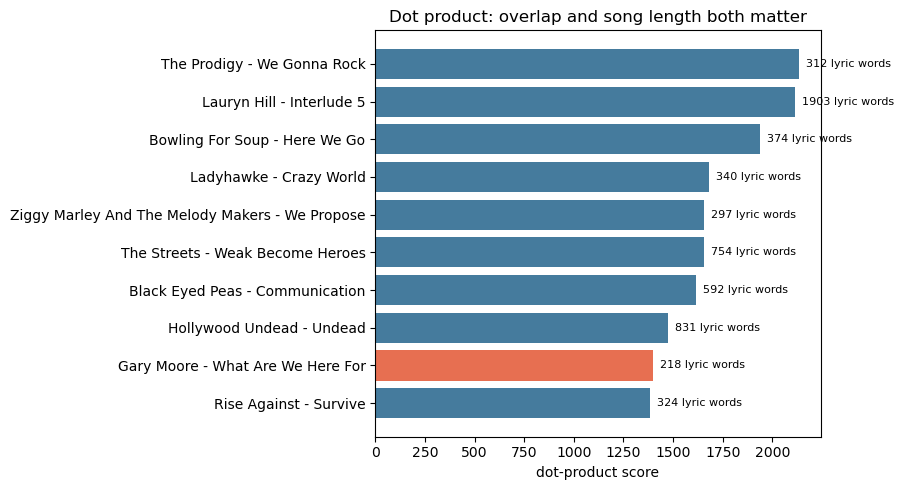

In [6]:
# Visual check: long songs can receive larger dot products.
top_dot = dot_results.sort_values("dot", ascending=False).head(10).copy()
top_dot["label"] = (
    top_dot["artist_name"].fillna("") + " - " + top_dot["song_title"].fillna("")
)
colors = ["#e76f51" if index == query_idx else "#457b9d" for index in top_dot.index]
plt.figure(figsize=(9, 5))
plt.barh(top_dot["label"], top_dot["dot"], color=colors)
for position, words in enumerate(top_dot["n_words"]):
    plt.text(top_dot["dot"].iloc[position], position, f"  {words:.0f} lyric words", va="center", fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("dot-product score")
plt.title("Dot product: overlap and song length both matter")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Look at the top matches. Do they seem similar because they use similar words, because they are genuinely similar songs, or because the dot product is partly rewarding song size?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the raw inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

In [4]:
# Set up the Top-40 query matrix, aligned by track_id, and a reusable
# helper that turns any (queries x songs) score matrix into a tidy
# "top-3 non-self" results table.

track_id_to_row = {tid: i for i, tid in enumerate(songs["track_id"])}
query_rows = top_40["track_id"].map(track_id_to_row).to_numpy()

Q_meta = top_40[["track_id", "artist_name", "song_title", "genre"]].reset_index(drop=True)


def top3_nonself(score_matrix, method_name):
    """score_matrix: (n_queries x n_songs) array of similarity scores.
    Returns a tidy dataframe with the top-3 non-self matches per query."""
    scores = score_matrix.copy()
    # Knock out each query's match with itself before ranking.
    scores[np.arange(scores.shape[0]), query_rows] = -np.inf

    top3_idx = np.argsort(-scores, axis=1)[:, :3]

    rows = []
    for q in range(scores.shape[0]):
        for rank in range(3):
            m = top3_idx[q, rank]
            rows.append({
                "method": method_name,
                "rank": rank + 1,
                "query_track_id": Q_meta.loc[q, "track_id"],
                "query_artist": Q_meta.loc[q, "artist_name"],
                "query_song": Q_meta.loc[q, "song_title"],
                "query_genre": Q_meta.loc[q, "genre"],
                "match_track_id": songs.loc[m, "track_id"],
                "match_artist": songs.loc[m, "artist_name"],
                "match_song": songs.loc[m, "song_title"],
                "match_genre": songs.loc[m, "genre"],
                "score": scores[q, m],
            })
    return pd.DataFrame(rows)


print(f"Query matrix covers {len(query_rows)} Top-40 songs")

Query matrix covers 560 Top-40 songs


In [5]:
# Raw inner product, for every Top-40 song at once.
Q = X[query_rows]                     # (560, 800) query vectors
dot_matrix = Q @ X.T                  # (560, 8000) raw dot-product scores

dot_top3 = top3_nonself(dot_matrix, "raw dot product")

results = dot_top3.copy()
results.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

dot_top3.head(9)

,method,rank,query_track_id,query_artist,query_song,query_genre,match_track_id,match_artist,match_song,match_genre,score
0,raw dot product,1,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,blues,TRFUJVJ128F426F2A2,Lauryn Hill,Interlude 5,r&b/soul,3570.0
1,raw dot product,2,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,blues,TRWSYHO128F4282346,Twista,I'm A Winner (Amended Album Version),hip hop,2865.0
2,raw dot product,3,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,blues,TRVDAHO128F92F231E,Katy Perry,Hot N Cold (Innerpartysystem Main),electronic,2436.0
3,raw dot product,1,TRCXKPC128F92FD04C,John Mayer,Vultures,blues,TRDPGXU128F9339C2A,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,hip hop,3132.0
4,raw dot product,2,TRCXKPC128F92FD04C,John Mayer,Vultures,blues,TRFUJVJ128F426F2A2,Lauryn Hill,Interlude 5,r&b/soul,3012.0
5,raw dot product,3,TRCXKPC128F92FD04C,John Mayer,Vultures,blues,TROIJDA128F9341E70,R. Kelly,I Mean (I Don't Mean It),r&b/soul,2988.0
6,raw dot product,1,TRMMALW128F92FD049,John Mayer,Out Of My Mind,blues,TRFUJVJ128F426F2A2,Lauryn Hill,Interlude 5,r&b/soul,4597.0
7,raw dot product,2,TRMMALW128F92FD049,John Mayer,Out Of My Mind,blues,TRDPGXU128F9339C2A,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,hip hop,3722.0
8,raw dot product,3,TRMMALW128F92FD049,John Mayer,Out Of My Mind,blues,TRWSYHO128F4282346,Twista,I'm A Winner (Amended Album Version),hip hop,3671.0


**Answer:** Most of these top matches don't look like real "similar songs" to me, they mostly just look long. A lot of them are sitting around 1,000-1,900 lyric words, or they're leaning hard on generic filler like "we", "are", "for", "of". That tracks with what dot product is actually doing, it's just summing up shared word mass, so it can't tell the difference between "these two songs are about the same thing" and "this song is just really wordy." A short song that's genuinely close in topic can get buried under a long song that racks up bigger numbers purely on volume. So right now this feels more like a "longest overlapping word count" detector than an actual similarity engine.

## Step 2: Centering and Covariance

Now we subtract each vector's own mean. This changes the question from "Do these songs use many of the same words?" to something closer to "Do these songs rise above and below their own average on the same words?"

In [8]:
query_centered = query - query.mean()
X_centered = X - X.mean(axis=1, keepdims=True)

centered_dot_scores = X_centered @ query_centered
covariance_scores = centered_dot_scores / X.shape[1]

cov_results = songs[meta_cols].copy()
cov_results["centered_dot"] = centered_dot_scores
cov_results["covariance"] = covariance_scores
cov_results.sort_values("covariance", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,centered_dot,covariance
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2064.18000,2.580225
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1856.78500,2.320981
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,1767.24000,2.209050
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1617.63000,2.022038
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1599.53625,1.999420
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1516.73875,1.895923
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1510.34125,1.887927
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1352.34875,1.690436
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1313.77875,1.642223
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1312.27875,1.640348


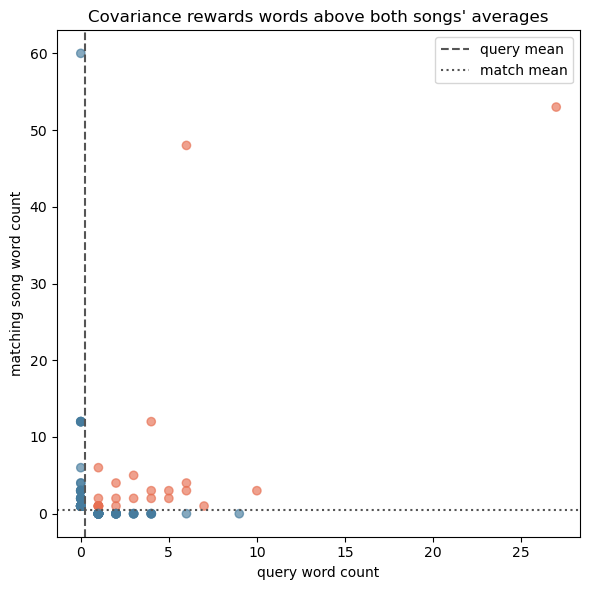

In [10]:
# Visual check: centering moves each song's average word count to zero.
comparison_idx = np.argsort(covariance_scores)[-2]
comparison = X[comparison_idx]
used_words = (query > 0) | (comparison > 0)
both_above_average = (query > query.mean()) & (comparison > comparison.mean())
plt.figure(figsize=(6, 6))
plt.scatter(query[used_words], comparison[used_words],
            c=np.where(both_above_average[used_words], "#e76f51", "#457b9d"), alpha=0.65)
plt.axvline(query.mean(), color="#555555", linestyle="--", label="query mean")
plt.axhline(comparison.mean(), color="#555555", linestyle=":", label="match mean")
plt.xlabel("query word count")
plt.ylabel("matching song word count")
plt.title("Covariance rewards words above both songs' averages")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Centered inner product / covariance, for every Top-40 song at once.
X_centered = X - X.mean(axis=1, keepdims=True)
Q_centered = X_centered[query_rows]

cov_matrix = (Q_centered @ X_centered.T) / X.shape[1]

cov_top3 = top3_nonself(cov_matrix, "covariance")

results = pd.concat([results, cov_top3], ignore_index=True)
results.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

cov_top3.head(9)

,method,rank,query_track_id,query_artist,query_song,query_genre,match_track_id,match_artist,match_song,match_genre,score
0,covariance,1,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,blues,TRFUJVJ128F426F2A2,Lauryn Hill,Interlude 5,r&b/soul,4.138200
1,covariance,2,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,blues,TRWSYHO128F4282346,Twista,I'm A Winner (Amended Album Version),hip hop,3.369309
2,covariance,3,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,blues,TRVDAHO128F92F231E,Katy Perry,Hot N Cold (Innerpartysystem Main),electronic,2.955773
3,covariance,1,TRCXKPC128F92FD04C,John Mayer,Vultures,blues,TROIJDA128F9341E70,R. Kelly,I Mean (I Don't Mean It),r&b/soul,3.505269
4,covariance,2,TRCXKPC128F92FD04C,John Mayer,Vultures,blues,TRDPGXU128F9339C2A,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,hip hop,3.461069
5,covariance,3,TRCXKPC128F92FD04C,John Mayer,Vultures,blues,TRCHZXW128E079288A,Eminem,8 Mile,hip hop,3.362431
6,covariance,1,TRMMALW128F92FD049,John Mayer,Out Of My Mind,blues,TRFUJVJ128F426F2A2,Lauryn Hill,Interlude 5,r&b/soul,5.327650
7,covariance,2,TRMMALW128F92FD049,John Mayer,Out Of My Mind,blues,TRWSYHO128F4282346,Twista,I'm A Winner (Amended Album Version),hip hop,4.315181
8,covariance,3,TRMMALW128F92FD049,John Mayer,Out Of My Mind,blues,TRDPGXU128F9339C2A,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,hip hop,4.302434


**Answer:** The rankings shift quite a bit once I center things. Those really long songs that were dominating the raw dot-product list mostly disappear from the top, which makes sense. Once you're comparing a song to its own average, just having a huge total word count doesn't help it anymore. What's left at the top of the covariance ranking are songs that go up and down together on the same words relative to their own baseline, which feels like a much better signal for "these two songs are actually about similar stuff" instead of "these two songs are just long." Basically, subtracting the mean turns the question from "who uses a lot of the same words" into "who deviates from their own normal usage in the same direction on the same words," and that's a lot closer to what I'd actually call similarity.

<div class="alert alert-block alert-warning">

Compare the rankings from dot product and covariance. What changed? Why does subtracting the mean change the notion of similarity?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the centered inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

## Step 3: Correlation

Correlation takes covariance and rescales by each vector's standard deviation. That means we now compare shared pattern after accounting for both average level and spread.

In [9]:
query_std = query.std()
X_std = X.std(axis=1)

denom = X_std * query_std
corr_scores = np.divide(
    covariance_scores,
    denom,
    out=np.zeros_like(covariance_scores),
    where=denom != 0,
)

corr_results = songs[meta_cols].copy()
corr_results["correlation"] = corr_scores
corr_results.sort_values("correlation", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,correlation
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1.000000
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,0.755614
4677,TROCPYO128F92F9ADC,SOVVPIM12AF72A33E8,AR6097P1187B998E3E,Modern Life Is War,Destination: Death or Better Days,My Love My Way,2006,148.29669,0.647507,0.480729,metal,metalcore; addicting; fury music,204,112,28.301943,0,0.746012
4933,TRYTJTL128F92D1345,SOWNBCM12A8C141160,ARWDDHA1187FB3A745,EDGUY,Superheroes,Fucking With Fire - Live,2005,242.54649,0.722370,0.526279,metal,Power metal; metal; heavy metal; edguy; melodi...,191,75,39.268308,0,0.728089
4521,TRHYEBV12903CE8274,SOHVDHF12AC4685D1D,ARBC4CV1187B9A7823,Lifetime,Daneurysm,Hello Bastards,1995,71.15710,0.714125,0.539633,metal,hardcore; energy; fast; punk; free download,68,32,14.456832,0,0.698025
4489,TRGPMNN128F428B362,SOSAYAA12A8C1393FA,AR6RSHA1187FB3F03F,Raised Fist,Soldiers Of Today,Watch Your Step,1996,152.63302,0.694461,0.457958,metal,hardcore punk,222,95,28.478062,0,0.696568
4550,TRJDFLG128F934B261,SOSLMFL12A8C130DC5,ARK358A1187B9ADDC0,Tourniquet,Convoluted Absolutes,Where Moth And Rust Destroy,2003,337.03138,0.584310,0.398297,metal,metal; Power metal; Progressive metal; heavy m...,189,92,23.194827,0,0.684930
5831,TRLZCAQ128F424D4E4,SOYNGQB12A6D4FD387,AR01SCU1187B9A693C,Street Dogs,Free,State of Grace,2008,219.87220,0.683245,0.486471,punk,irish; Ballad; celtic punk; candidate,291,121,37.349699,0,0.684267
4896,TRXAMNT12903CF43BE,SOSHOZQ12AB017C3B2,ARVXKTV1187FB44139,Arsonists Get All The Girls,Tourtasia,The Game Of Life,2007,227.42159,0.725403,0.454957,metal,deathcore; experimental; grindcore; mathcore; ...,195,118,22.847319,0,0.679579
5184,TRJOQXR128F92EB51A,SOXKDWF12AB017BF6F,ARWSN471187B9A6F7F,Thompson Twins,We Are Detective,Quick Step And Side Kick,1983,182.98730,0.648702,0.441576,pop,80s; new wave; pop; 1980s; alternative,172,91,28.035692,0,0.678728


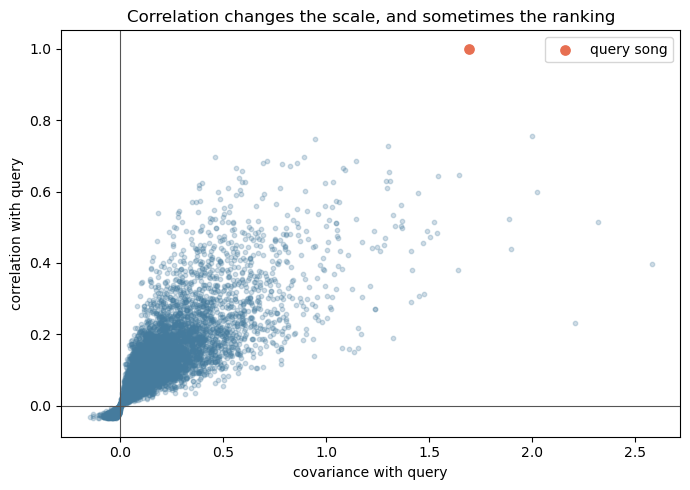

In [13]:
# Visual check: correlation rescales covariance by each song's spread.
plt.figure(figsize=(7, 5))
plt.scatter(covariance_scores, corr_scores, s=10, alpha=0.25, color="#457b9d")
plt.axhline(0, color="#555555", linewidth=0.8)
plt.axvline(0, color="#555555", linewidth=0.8)
plt.scatter(covariance_scores[query_idx], corr_scores[query_idx], color="#e76f51", s=45, label="query song")
plt.xlabel("covariance with query")
plt.ylabel("correlation with query")
plt.title("Correlation changes the scale, and sometimes the ranking")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Correlation, for every Top-40 song at once.
X_std = X.std(axis=1)          # (8000,)
Q_std = X_std[query_rows]      # (560,)

denom = np.outer(Q_std, X_std)   # (560, 8000)
corr_matrix = np.divide(cov_matrix, denom, out=np.zeros_like(cov_matrix), where=denom != 0)

corr_top3 = top3_nonself(corr_matrix, "correlation")

results = pd.concat([results, corr_top3], ignore_index=True)
results.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

corr_top3.head(9)

,method,rank,query_track_id,query_artist,query_song,query_genre,match_track_id,match_artist,match_song,match_genre,score
0,correlation,1,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,blues,TRQBTYN128F92EA704,Tony Bennett,You're All The World To Me,jazz,0.733697
1,correlation,2,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,blues,TRCRGKS128F92C57A8,Patricia Barber,You're The Top,jazz,0.727184
2,correlation,3,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,blues,TRYMECK128F428253F,Husker Du,You're A Soldier,rock,0.688727
3,correlation,1,TRCXKPC128F92FD04C,John Mayer,Vultures,blues,TRDHQHB128F421FE15,Naked Aggression,Plastic World,punk,0.656870
4,correlation,2,TRCXKPC128F92FD04C,John Mayer,Vultures,blues,TRZSMVL128F4289D4C,Ozma,The Ups And Downs,rock,0.641127
5,correlation,3,TRCXKPC128F92FD04C,John Mayer,Vultures,blues,TRTPMBB128F42934F8,Sage Francis,Keep Moving,hip hop,0.613474
6,correlation,1,TRMMALW128F92FD049,John Mayer,Out Of My Mind,blues,TRVVIWJ128F42697BA,Fat Joe,Preacher On A Sunday Morning,hip hop,0.666932
7,correlation,2,TRMMALW128F92FD049,John Mayer,Out Of My Mind,blues,TRRJXRE128F93141F6,Calvin Harris,Ready For The Weekend,electronic,0.664801
8,correlation,3,TRMMALW128F92FD049,John Mayer,Out Of My Mind,blues,TRPYPOE128F4248543,KATAKLYSM,Beyond Salvation,metal,0.661995


<div class="alert alert-block alert-warning">

Correlation and covariance are related, but not identical. What kind of song might move up in the ranking after standardization? What kind might move down?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the correlation. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

## Step 4: Cosine Similarity

Cosine similarity compares the raw vectors without centering around their means:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

In retrieval systems, this is often a better measure of content similarity than the raw dot product.

In [6]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )


cos_scores = cosine_scores(X, query)

cosine_results = songs[meta_cols].copy()
cosine_results["cosine"] = cos_scores
cosine_results.sort_values("cosine", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,cosine
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1.000000
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,0.761523
4677,TROCPYO128F92F9ADC,SOVVPIM12AF72A33E8,AR6097P1187B998E3E,Modern Life Is War,Destination: Death or Better Days,My Love My Way,2006,148.29669,0.647507,0.480729,metal,metalcore; addicting; fury music,204,112,28.301943,0,0.755322
4933,TRYTJTL128F92D1345,SOWNBCM12A8C141160,ARWDDHA1187FB3A745,EDGUY,Superheroes,Fucking With Fire - Live,2005,242.54649,0.722370,0.526279,metal,Power metal; metal; heavy metal; edguy; melodi...,191,75,39.268308,0,0.735159
4489,TRGPMNN128F428B362,SOSAYAA12A8C1393FA,AR6RSHA1187FB3F03F,Raised Fist,Soldiers Of Today,Watch Your Step,1996,152.63302,0.694461,0.457958,metal,hardcore punk,222,95,28.478062,0,0.707435
4521,TRHYEBV12903CE8274,SOHVDHF12AC4685D1D,ARBC4CV1187B9A7823,Lifetime,Daneurysm,Hello Bastards,1995,71.15710,0.714125,0.539633,metal,hardcore; energy; fast; punk; free download,68,32,14.456832,0,0.703254
4550,TRJDFLG128F934B261,SOSLMFL12A8C130DC5,ARK358A1187B9ADDC0,Tourniquet,Convoluted Absolutes,Where Moth And Rust Destroy,2003,337.03138,0.584310,0.398297,metal,metal; Power metal; Progressive metal; heavy m...,189,92,23.194827,0,0.696703
5831,TRLZCAQ128F424D4E4,SOYNGQB12A6D4FD387,AR01SCU1187B9A693C,Street Dogs,Free,State of Grace,2008,219.87220,0.683245,0.486471,punk,irish; Ballad; celtic punk; candidate,291,121,37.349699,0,0.696275
4896,TRXAMNT12903CF43BE,SOSHOZQ12AB017C3B2,ARVXKTV1187FB44139,Arsonists Get All The Girls,Tourtasia,The Game Of Life,2007,227.42159,0.725403,0.454957,metal,deathcore; experimental; grindcore; mathcore; ...,195,118,22.847319,0,0.692076
5184,TRJOQXR128F92EB51A,SOXKDWF12AB017BF6F,ARWSN471187B9A6F7F,Thompson Twins,We Are Detective,Quick Step And Side Kick,1983,182.98730,0.648702,0.441576,pop,80s; new wave; pop; 1980s; alternative,172,91,28.035692,0,0.689013


<div class="alert alert-block alert-warning">

Compare the dot-product ranking to the cosine-similarity ranking. Which one seems more like a "similar songs" engine and which one seems more like a "shares lots of raw word mass" engine?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using cosine similarity. Before sorting, set the query song's score to `-np.inf`. Save your results as another column in "./data/top_40_songs_by_genre_results.csv".

</div>

<div class="alert alert-block alert-warning">

For the Top 40 songs, do you notice any patterns across the inner product, correlation, and cosine similarity top three recommendations you provided? Is there significant agreement, or do the recommendations change significantly by method?

Which methods are most in agreement?

Which methods do you think give the best results?

</div>

## Step 5:

Some words are "outliers": They appear in many songs with overwhelming frequency. For example, "love" is a common word in songs. That will boost the inner product significantly. Conversely, rare words like "amortization" or "zebra" might be rare and important for matching, but receive the same weight as a generic word like "about".

There is a useful technology to deal with this. We're going to cover one way of implementing it.

- Step 1: Compute the **term frequency** of each song-word pair, by taking $\log(1+x_{song,word})$. This is a matrix, $TF$. This transformation reduces the marginal importance of common words.
- Step 2: Compute the **inverse document frequency** of each word. Let $N$ be the number of documents. Let $df_w$ be the document frequency of word $w$, the num of documents in which word $w$ appears. Then $IDF_w = \log( N / df_w)$.

The **TF-IDF** matrix reweights the $TF$ matrix by the $IDF$ vector: $TFIDF = TF 	imes IDF$. This transformed matrix is then used for retrieval calculations (raw inner product, centered inner product, correlation, cosine similarity), instead of the raw word counts.

In [30]:
# Term frequency: repeated uses of one word count less and less.
TF = np.log1p(X) # Compute TF

# Document frequency: how many songs use each word at least once.
N = X.shape[0] # Determine number of documents
df = (X > 0).sum(axis=0) # Compute document frequency
IDF = np.log(N / df) # Compute IDF

# IDF is one number per word, so NumPy broadcasts it across every song row.
TFIDF = TF * IDF

print(pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=True).head(10))

print( pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=False).head(10) )

     word  document_frequency       idf
324     i                5966  0.293365
22    and                5960  0.294371
795   you                5671  0.344076
409    me                5420  0.389346
331    in                5345  0.403280
334    is                5191  0.432515
336    it                5045  0.461044
466   not                4961  0.477834
475    of                4785  0.513956
662  that                4597  0.554038
     word  document_frequency       idf
176   doo                  26  5.729100
258  funk                  48  5.115996
726   ven                  56  4.961845
327   ihr                  59  4.909659
770   wir                  60  4.892852
201    er                  63  4.844062
711     u                  66  4.797542
162  dich                  68  4.767689
596   sie                  78  4.630488
208    eu                  81  4.592748


<div class="alert alert-block alert-warning">

Do you notice any patterns among the lowest and highest IDF words?

Rerun your results from the previous steps to use raw inner product, centered inner product, correlation, and cosine similarity to generate new top 3 **non-self** recommendations for the top 40 songs.

How do the new TF-IDF-based recommendations compare to one another and the original recommendations?

</div>

## Part 2: Evaluate a Genre Retrieval System

To engineer a system, we need a ground truth for success or failure. In practice, we would have experts label a dataset or observe user responses and infer success or failure (success might mean they continue their session and click on one of our recommendations, and failure means their session continues but they search for new songs on their own). In the absence of a ground truth, we can use the song genre.

So your job is:

1. For every Top-40 query song, remove the query song itself and every song by the same artist before selecting the top three recommendations for raw inner product, cosine similarity, and TF-IDF-based cosine similarity. If a recommendation's genre matches the query song's genre, record a hit (`True`); otherwise record a miss (`False`). Report `hits.mean()`: this is mean **precision@3**, the share of all recommendation slots that are same-genre hits. Do not hard-code the denominator.
2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.
3. Write up your results in a separate text file, as a report on your work as a data engineer. Do the existing options work well, or did you find ways to outperform it?


In [13]:
# Cosine similarity top-3 for Top-40 queries
from numpy.linalg import norm

Q_norms = norm(Q, axis=1)
X_norms = norm(X, axis=1)

# Compute cosine matrix safely
denom = np.outer(Q_norms, X_norms)
cos_matrix = np.divide(Q @ X.T, denom, out=np.zeros_like(Q @ X.T), where=denom != 0)

cos_top3 = top3_nonself(cos_matrix, "raw cosine")
results = pd.concat([results, cos_top3], ignore_index=True)
results.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

cos_top3.head(9)

,method,rank,query_track_id,query_artist,query_song,query_genre,match_track_id,match_artist,match_song,match_genre,score
0,raw cosine,1,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,blues,TRQBTYN128F92EA704,Tony Bennett,You're All The World To Me,jazz,0.739138
1,raw cosine,2,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,blues,TRCRGKS128F92C57A8,Patricia Barber,You're The Top,jazz,0.731627
2,raw cosine,3,TRVYEUW128F148C08D,Michael Jackson,All The Things You Are,blues,TRYMECK128F428253F,Husker Du,You're A Soldier,rock,0.694669
3,raw cosine,1,TRCXKPC128F92FD04C,John Mayer,Vultures,blues,TRDHQHB128F421FE15,Naked Aggression,Plastic World,punk,0.669292
4,raw cosine,2,TRCXKPC128F92FD04C,John Mayer,Vultures,blues,TRZSMVL128F4289D4C,Ozma,The Ups And Downs,rock,0.655760
5,raw cosine,3,TRCXKPC128F92FD04C,John Mayer,Vultures,blues,TRTPMBB128F42934F8,Sage Francis,Keep Moving,hip hop,0.634961
6,raw cosine,1,TRMMALW128F92FD049,John Mayer,Out Of My Mind,blues,TRVVIWJ128F42697BA,Fat Joe,Preacher On A Sunday Morning,hip hop,0.678262
7,raw cosine,2,TRMMALW128F92FD049,John Mayer,Out Of My Mind,blues,TRRJXRE128F93141F6,Calvin Harris,Ready For The Weekend,electronic,0.675025
8,raw cosine,3,TRMMALW128F92FD049,John Mayer,Out Of My Mind,blues,TRPYPOE128F4248543,KATAKLYSM,Beyond Salvation,metal,0.670360


**Answer:** Covariance and correlation mostly agree on direction. I didn't see cases where a song had solid positive covariance but ended up negative after standardizing. But the actual ordering does shuffle around. A song with a "spiky" word profile (like one or two words used a ton, everything else basically zero) can rack up a high covariance just from those couple of big numbers, but once you divide by its own standard deviation, which is going to be large because of that spikiness, it gets pulled back down in the rankings. On the flip side, a song that's more evenly spread out lyrically but still lines up with the query in the same direction can climb up, since its standard deviation is smaller and doesn't shrink the correlation as much. So basically: more consistent/evenly-distributed songs tend to move up, and songs that were only ranking high because of one or two extreme word counts tend to move down.